# Automated Exoplanet Detection from Space Telescope Data

COMP702 MSc Project — Prarthana Voosala (201946897)

This notebook builds and compares three machine learning models that classify
NASA Kepler Objects of Interest (KOIs) as **planet candidates** or **false
positives**, using the cumulative KOI table from the NASA Exoplanet Archive.

The three models are Logistic Regression, Random Forest and a Multi-Layer
Perceptron. All three run through the same preprocessing, the same train/test
split and the same evaluation metrics, so any difference in performance comes
from the model itself rather than from how the data was prepared.

Running this notebook top to bottom regenerates everything the Streamlit demo
(`app.py`) displays: the fitted pipelines in `models/` and the metric tables
and figures in `results/`.

## 1. Setup

`RANDOM_STATE` is fixed and passed to every component that has a random element
— the train/test split, the cross-validation folds, the hyperparameter search
and the models themselves. Without this the results would shift slightly on
each run and would not be reproducible for the dissertation.

In [1]:
import os
import time
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.model_selection import (
    GroupShuffleSplit, StratifiedGroupKFold, cross_val_score, RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)

# One seed for every stochastic step, so the whole notebook is reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Figures are written straight into results/ alongside the metric tables, so
# there is a single place holding everything the report and the demo app use.
FIGURE_DIR = "results"
os.makedirs(FIGURE_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 2. Loading the KOI catalogue

The cumulative KOI table is distributed as a CSV with a block of `#` comment
lines at the top describing each column, which is why `comment="#"` is needed.

The file is not committed to the repository (it is listed in `.gitignore`), so
the check below fails with a useful message rather than a bare `FileNotFoundError`
if it has not been downloaded yet.

In [3]:
DATA_PATH = "data/datacumulative_koi.csv"

if not os.path.exists(DATA_PATH):
    available = os.listdir("data") if os.path.exists("data") else []
    raise FileNotFoundError(f"Can't find '{DATA_PATH}'. Files in data/: {available}")

df = pd.read_csv(DATA_PATH, comment="#")
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 9564 rows, 141 columns


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200


## 3. First look at the data

Before any modelling, three questions need answering: how the classes are
balanced, how much data is missing, and whether the headline physical
measurements look sensible.

`koi_disposition` is the label assigned by the Kepler vetting process. It takes
three values of interest: `CONFIRMED` (verified planet), `CANDIDATE` (passed
vetting but not yet independently confirmed) and `FALSE POSITIVE` (ruled out).

In [4]:
print(df['koi_disposition'].value_counts())
print()
print(df['koi_disposition'].value_counts(normalize=True).round(3))

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

koi_disposition
FALSE POSITIVE    0.506
CONFIRMED         0.287
CANDIDATE         0.207
Name: proportion, dtype: float64


### 3.1 Missing values

Many KOI columns are only populated for a subset of objects, so it is worth
seeing how severe that is before deciding what to keep. The worst offenders are
plotted below; the actual filtering happens in section 7, using only the
training set so that the test set has no influence on the decision.

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15)

koi_incl_err1       100.0
koi_sma_err2        100.0
koi_sma_err1        100.0
koi_teq_err1        100.0
koi_teq_err2        100.0
koi_longp_err2      100.0
koi_ingress         100.0
koi_ingress_err2    100.0
koi_ingress_err1    100.0
koi_longp_err1      100.0
koi_longp           100.0
koi_eccen_err2      100.0
koi_eccen_err1      100.0
koi_sage_err1       100.0
koi_sage_err2       100.0
dtype: float64

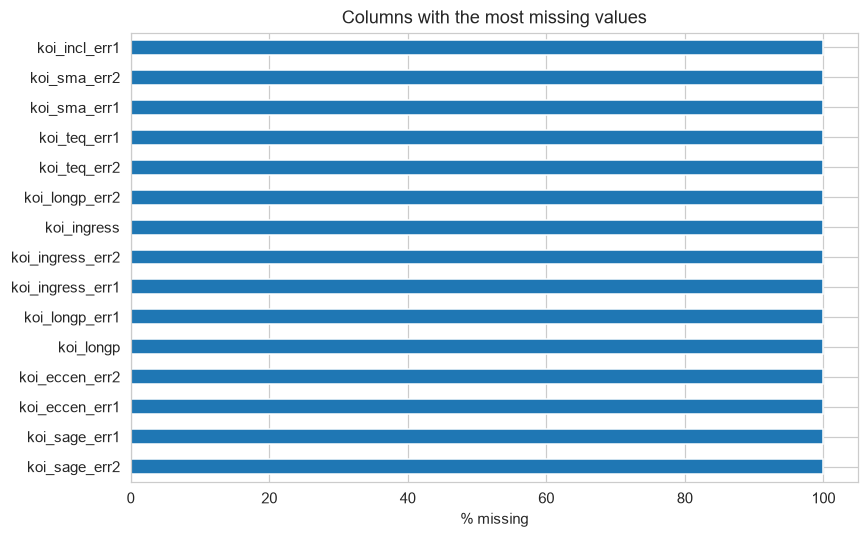

In [6]:
plt.figure(figsize=(8, 5))
missing_pct.head(15).iloc[::-1].plot(kind="barh")
plt.xlabel("% missing")
plt.title("Columns with the most missing values")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/outputs_missingness.png", bbox_inches="tight")
plt.show()

### 3.2 The main physical measurements

These are the quantities an astronomer would look at first: orbital period,
transit depth and duration, planetary radius, equilibrium temperature,
insolation, and the host star's effective temperature and radius.

In [7]:
key_features = [c for c in ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad', 'koi_teq',
                            'koi_insol', 'koi_steff', 'koi_srad'] if c in df.columns]
df[key_features].describe().T

,count,mean,std,min,25%,50%,75%,max
koi_period,9564.0,75.671358,1334.744046,0.241843,2.733684,9.752831,40.715178,1.299958e+05
koi_depth,9201.0,23791.335898,82242.683149,0.000000,159.900000,421.100000,1473.400000,1.541400e+06
koi_duration,9564.0,5.621606,6.471554,0.052000,2.437750,3.792600,6.276500,1.385400e+02
koi_prad,9201.0,102.891778,3077.639126,0.080000,1.400000,2.390000,14.930000,2.003460e+05
koi_teq,9201.0,1085.385828,856.351161,25.000000,539.000000,878.000000,1379.000000,1.466700e+04
koi_insol,9243.0,7745.737023,159204.665200,0.000000,20.150000,141.600000,870.290000,1.094755e+07
koi_steff,9201.0,5706.823280,796.857947,2661.000000,5310.000000,5767.000000,6112.000000,1.589600e+04
koi_srad,9201.0,1.728712,6.127185,0.109000,0.829000,1.000000,1.345000,2.299080e+02


## 4. Defining the classification target

The task is framed as binary classification. Anything not ruled out by vetting
counts as the positive class, so `CONFIRMED` and `CANDIDATE` are grouped
together against `FALSE POSITIVE`.

This models the **triage** decision — "is this signal worth following up?" —
rather than "is this definitely a planet". Grouping `CANDIDATE` with `CONFIRMED`
is a deliberate choice with a known trade-off: candidates have not been
independently verified, so a proportion of the positive labels are uncertain.
The alternative, training only on `CONFIRMED` against `FALSE POSITIVE`, gives
cleaner labels but discards a large share of the data and answers a different
question.

In [8]:
df = df[df['koi_disposition'].isin(['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'])].copy()
df['target'] = (df['koi_disposition'] != 'FALSE POSITIVE').astype(int)

print(f"Rows after filtering: {len(df)}")
print(df['target'].value_counts(normalize=True).round(3))

Rows after filtering: 9564
target
0    0.506
1    0.494
Name: proportion, dtype: float64


## 5. Removing leakage and identifier columns

This is the step that most affects whether the results mean anything. The KOI
table ships with columns produced *by* the vetting process that decided the
label. Leaving any of them in would let a model reproduce the answer instead of
predicting it, and the reported scores would be meaningless.

Two passes are used. The first lists the columns known to be unsafe, each with
the reason it is removed. The second sweeps the remaining column names for
vetting-related keywords, to catch anything the manual list missed.

In [9]:
# Columns removed because they encode the answer, plus identifiers that carry
# no physical meaning. The reason is recorded alongside each one so the choice
# can be justified in the dissertation and exported as evidence later.
leakage_reasons = {
    'koi_disposition': 'this is the label we filtered on to build the target',
    'koi_pdisposition': 'disposition produced by the automated vetting pipeline',
    'koi_score': 'a confidence score tied to the vetting/disposition process',
    'koi_fpflag_nt': 'false-positive flag set during vetting',
    'koi_fpflag_ss': 'false-positive flag set during vetting',
    'koi_fpflag_co': 'false-positive flag set during vetting',
    'koi_fpflag_ec': 'false-positive flag set during vetting',
    'kepoi_name': 'identifier, not a physical measurement',
    'kepler_name': 'only assigned once a KOI is confirmed, so its presence gives the answer away',
}

In [10]:
# Second pass: search every remaining column name for vetting-related keywords,
# in case the manual list above missed something.
suspicious_keywords = ['disposition', 'pdisposition', 'score', 'fpflag', 'comment',
                       'vet', 'disp_prov', 'delivname']
already_flagged = set(leakage_reasons.keys())

suspicious_found = [c for c in df.columns
                    if any(k in c.lower() for k in suspicious_keywords) and c not in already_flagged]

print("Columns matching vetting/disposition-related keywords that weren't already in my leakage table:")
for c in suspicious_found:
    print(" -", c)

if not suspicious_found:
    print("(none found beyond the ones already listed above)")

Columns matching vetting/disposition-related keywords that weren't already in my leakage table:
 - koi_vet_stat
 - koi_vet_date
 - koi_disp_prov
 - koi_comment
 - koi_tce_delivname


In [11]:
# The keyword sweep found these five, so they join the removal list.
leakage_reasons['koi_vet_stat'] = 'vetting status produced during the KOI vetting process'
leakage_reasons['koi_vet_date'] = 'date associated with the vetting process'
leakage_reasons['koi_disp_prov'] = 'disposition provenance/processing metadata'
leakage_reasons['koi_comment'] = 'vetting-related comments or notes'
leakage_reasons['koi_tce_delivname'] = 'processing/delivery metadata from the TCE pipeline'

In [12]:
# Exported to results/ later as a record of exactly what was excluded and why.
leakage_table = pd.DataFrame([
    {'column': col, 'reason_removed': reason}
    for col, reason in leakage_reasons.items()
    if col in df.columns
])

leakage_table

,column,reason_removed
0,koi_disposition,this is the label we filtered on to build the ...
1,koi_pdisposition,disposition produced by the automated vetting ...
2,koi_score,a confidence score tied to the vetting/disposi...
3,koi_fpflag_nt,false-positive flag set during vetting
4,koi_fpflag_ss,false-positive flag set during vetting
5,koi_fpflag_co,false-positive flag set during vetting
6,koi_fpflag_ec,false-positive flag set during vetting
7,kepoi_name,"identifier, not a physical measurement"
8,kepler_name,"only assigned once a KOI is confirmed, so its ..."
9,koi_vet_stat,vetting status produced during the KOI vetting...


In [13]:
cols_to_drop = [c for c in leakage_reasons if c in df.columns]
feature_df = df.drop(columns=cols_to_drop)

print(f"Columns before removing leakage/identifier fields: {df.shape[1]}")
print(f"Columns after: {feature_df.shape[1]}")

Columns before removing leakage/identifier fields: 142
Columns after: 128


## 6. Splitting by host star

A plain random split would be optimistic here. One star can host several KOIs,
and those share the same stellar properties (temperature, radius, magnitude).
If some land in training and others in test, the model can recognise the star
rather than the transit, and the test score overstates real performance.

`GroupShuffleSplit` grouped on `kepid` (the Kepler Input Catalogue star ID)
keeps every KOI belonging to one star entirely on one side of the split. The
same grouping is applied to the cross-validation folds later.

`target` and `kepid` are both excluded from the feature matrix: `target` is the
label, and `kepid` is only a grouping key.

In [14]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['target', 'kepid']]

X_all = feature_df[numeric_cols]
y_all = feature_df['target']
groups_all = feature_df['kepid'] if 'kepid' in feature_df.columns else pd.Series(np.arange(len(feature_df)))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))

X_train_raw = X_all.iloc[train_idx].reset_index(drop=True)
X_test_raw = X_all.iloc[test_idx].reset_index(drop=True)
y_train = y_all.iloc[train_idx].reset_index(drop=True)
y_test = y_all.iloc[test_idx].reset_index(drop=True)
groups_train = groups_all.iloc[train_idx].reset_index(drop=True)

print(f"Training rows: {len(X_train_raw)}, test rows: {len(X_test_raw)}")
print(f"Unique host stars in training set: {groups_train.nunique()}")

Training rows: 7662, test rows: 1902
Unique host stars in training set: 6571


In [15]:
# Export the held-out 20% so the Streamlit app can be demonstrated on data the
# models genuinely never saw during training.
test_dataset = feature_df.iloc[test_idx].copy()
test_dataset.to_csv("test_dataset_20_percent.csv", index=False)

print("Test dataset saved successfully!")
print(f"Test rows: {len(test_dataset)}")
print(f"Total rows: {len(feature_df)}")
print(f"Test percentage: {len(test_dataset) / len(feature_df) * 100:.2f}%")
print(f"Unique test host stars: {test_dataset['kepid'].nunique()}")

Test dataset saved successfully!
Test rows: 1902
Total rows: 9564
Test percentage: 19.89%
Unique test host stars: 1643


## 7. Choosing which features to keep

Two filters, both computed on the **training set only**. Using the full dataset
here would leak information about the test set into the feature selection.

1. **Missingness** — drop any column missing in more than half of training rows.
   Imputing a median into a mostly-empty column invents data rather than
   recovering it.
2. **Correlation** — where two columns correlate above 0.95 they carry
   essentially the same information. One of each pair is dropped: this mainly
   removes duplicated measurement/uncertainty pairs, and it makes the Logistic
   Regression coefficients more stable and easier to interpret.

In [16]:
missing_frac_train = X_train_raw.isna().mean()
keep_cols = missing_frac_train[missing_frac_train < 0.5].index.tolist()

print(f"Candidate numeric features: {X_train_raw.shape[1]}")
print(f"Features kept after the >50%-missing-in-training filter: {len(keep_cols)}")
print(f"Features dropped: {sorted(set(X_train_raw.columns) - set(keep_cols))}")

Candidate numeric features: 118
Features kept after the >50%-missing-in-training filter: 99
Features dropped: ['koi_eccen_err1', 'koi_eccen_err2', 'koi_incl_err1', 'koi_incl_err2', 'koi_ingress', 'koi_ingress_err1', 'koi_ingress_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2', 'koi_model_chisq', 'koi_model_dof', 'koi_sage', 'koi_sage_err1', 'koi_sage_err2', 'koi_sma_err1', 'koi_sma_err2', 'koi_teq_err1', 'koi_teq_err2']


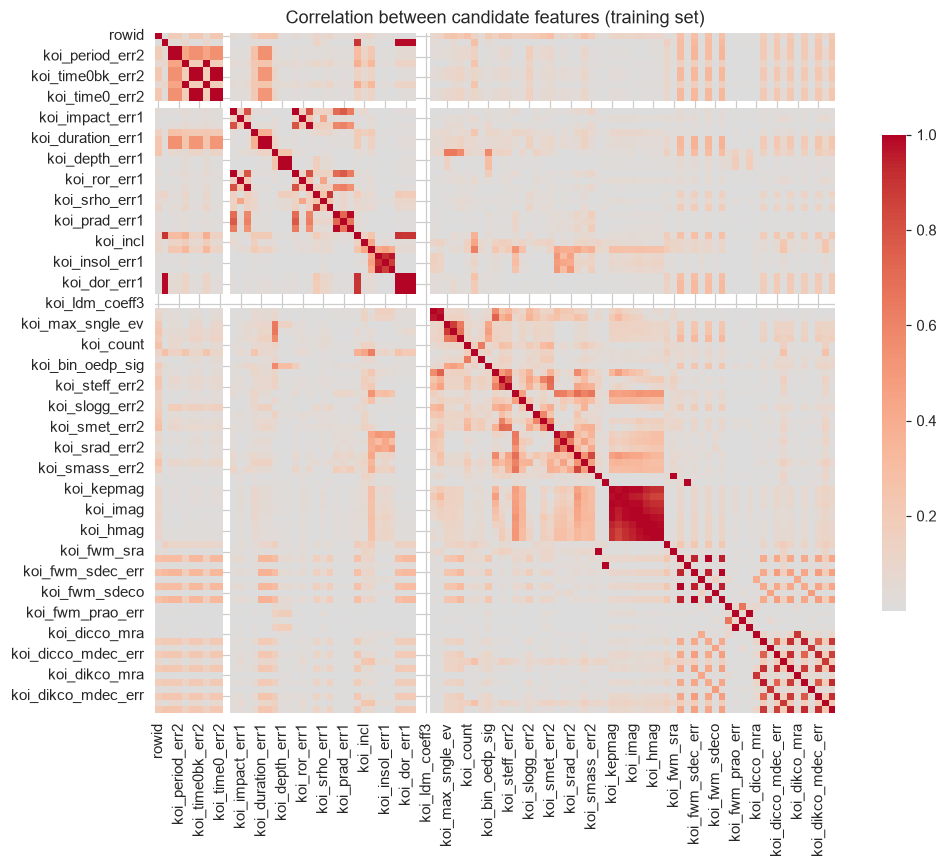

In [17]:
corr_matrix = X_train_raw[keep_cols].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation between candidate features (training set)")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/outputs_correlation.png", bbox_inches="tight")
plt.show()

In [18]:
# Take the upper triangle only, so each pair is considered once rather than twice.
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated = [(row, col) for col in upper.columns for row in upper.index
                     if upper.loc[row, col] and upper.loc[row, col] > 0.95]

print("Highly correlated pairs (>0.95):")
for pair in highly_correlated:
    print(f"  {pair[0]}  <->  {pair[1]}   (corr = {corr_matrix.loc[pair[0], pair[1]]:.3f})")

# Drop the second column of each correlated pair, keeping the first.
to_drop_corr = sorted({pair[1] for pair in highly_correlated})
final_cols = [c for c in keep_cols if c not in to_drop_corr]

print(f"\nDropping {len(to_drop_corr)} redundant feature(s): {to_drop_corr}")
print(f"Final feature count: {len(final_cols)}")

Highly correlated pairs (>0.95):
  koi_period_err1  <->  koi_period_err2   (corr = 1.000)
  koi_time0bk_err1  <->  koi_time0bk_err2   (corr = 1.000)
  koi_time0bk  <->  koi_time0   (corr = 1.000)
  koi_time0bk_err1  <->  koi_time0_err1   (corr = 1.000)
  koi_time0bk_err2  <->  koi_time0_err1   (corr = 1.000)
  koi_time0bk_err1  <->  koi_time0_err2   (corr = 1.000)
  koi_time0bk_err2  <->  koi_time0_err2   (corr = 1.000)
  koi_time0_err1  <->  koi_time0_err2   (corr = 1.000)
  koi_duration_err1  <->  koi_duration_err2   (corr = 1.000)
  koi_depth_err1  <->  koi_depth_err2   (corr = 1.000)
  koi_impact  <->  koi_ror   (corr = 0.995)
  koi_impact_err1  <->  koi_ror_err1   (corr = 1.000)
  koi_impact_err2  <->  koi_ror_err2   (corr = 0.985)
  koi_prad  <->  koi_prad_err2   (corr = 0.988)
  koi_insol  <->  koi_insol_err2   (corr = 0.966)
  koi_period  <->  koi_dor   (corr = 0.992)
  koi_period  <->  koi_dor_err1   (corr = 0.991)
  koi_dor  <->  koi_dor_err1   (corr = 0.996)
  koi_period  <-

In [19]:
X_train = X_train_raw[final_cols].reset_index(drop=True)
X_test = X_test_raw[final_cols].reset_index(drop=True)

print("Feature preparation summary:")
print(f"  candidate numeric columns : {X_train_raw.shape[1]}")
print(f"  after missingness filter  : {len(keep_cols)}")
print(f"  after correlation filter  : {len(final_cols)}")

Feature preparation summary:
  candidate numeric columns : 118
  after missingness filter  : 99
  after correlation filter  : 70


In [20]:
# rowid is the archive's row counter, not a measurement. It survives both
# filters above because it is fully populated and uncorrelated with anything,
# so it has to be removed explicitly.
X_train = X_train.drop(columns=['rowid'], errors='ignore')
X_test = X_test.drop(columns=['rowid'], errors='ignore')

# The list the models are actually trained on. Section 14 saves this rather
# than final_cols, which still contains rowid at this point.
model_feature_cols = list(X_train.columns)

print(f"Final training features: {X_train.shape[1]}")

Final training features: 69


## 8. Model pipelines

Each model is wrapped in a `Pipeline` so that preprocessing is fitted inside
cross-validation rather than before it. If the imputer and scaler were fitted
on the whole training set up front, every validation fold would be contaminated
by statistics drawn from the rows it is meant to be evaluating.

Median imputation is used throughout — the KOI measurements are skewed, so the
median is a safer fill value than the mean.

Only Logistic Regression and the MLP get a `StandardScaler`. Both are sensitive
to feature magnitude: Logistic Regression because its coefficients are penalised
by `C`, and the MLP because gradient descent converges poorly on inputs at
wildly different scales. A Random Forest splits on thresholds one feature at a
time, so scaling would change nothing.

In [21]:
lr_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

# No scaler: tree splits are threshold-based and unaffected by feature scale.
rf_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])

mlp_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
])

pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "MLP": mlp_pipeline,
}

## 9. Baseline models

Fitted with default-ish settings first. These baselines are what the tuned
models in section 11 have to beat — without them there is no way to tell
whether hyperparameter search actually bought anything.

In [22]:
baseline_fitted = {}
for name, pipe in pipelines.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    baseline_fitted[name] = pipe
    print(f"{name}: fitted in {time.time() - t0:.1f}s")

Logistic Regression: fitted in 0.4s
Random Forest: fitted in 5.5s
MLP: fitted in 21.9s


## 10. Cross-validation

A single train/test split gives one number per model and no sense of how much
of it is chance. Five-fold cross-validation on the training set gives a mean and
a spread instead.

`StratifiedGroupKFold` does two things at once: **stratified** keeps the class
balance steady across folds, and **group** enforces the same host-star
separation used for the main split, so the folds do not leak stars into one
another either.

F1 is the scoring metric because the classes are imbalanced, which makes
accuracy a poor guide.

In [23]:
cv_report = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_report, groups=groups_train,
                             scoring="f1", n_jobs=-1)
    cv_results.append({"Model": name, "Mean F1 (CV)": scores.mean(), "Std F1 (CV)": scores.std()})

pd.DataFrame(cv_results).round(3).set_index("Model")

,Mean F1 (CV),Std F1 (CV)
Model,,
Logistic Regression,0.860,0.003
Random Forest,0.894,0.004
MLP,0.861,0.003


## 11. Hyperparameter tuning

`RandomizedSearchCV` samples 8 combinations per model rather than testing every
one. A full grid search over the Random Forest and MLP spaces would take far
longer for very little gain, since most of the improvement comes from a few
influential parameters.

Three folds are used here instead of five to keep the search affordable —
tuning fits 8 x 3 = 24 models per algorithm. The grouping is still applied, so
the tuning process cannot leak across host stars either.

The test set plays no part in any of this. It is only touched in section 12.

In [24]:
cv_tune = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    # C is the inverse regularisation strength: lower means a stronger penalty.
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10, 100]},
    # Forest size, tree depth, and how many samples a node needs before splitting.
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
    },
    # Network shape, L2 penalty, and initial learning rate.
    "MLP": {
        "model__hidden_layer_sizes": [(32,), (64, 32), (100, 50)],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.001, 0.01],
    },
}

tuned_fitted = {}
tuning_summary = []

for name, pipe in pipelines.items():
    t0 = time.time()
    search = RandomizedSearchCV(
        pipe, param_distributions[name], n_iter=8, cv=cv_tune, scoring="f1",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_train, y_train, groups=groups_train)
    tuned_fitted[name] = search.best_estimator_
    tuning_summary.append({
        "Model": name,
        "Best params": search.best_params_,
        "Best CV F1": round(search.best_score_, 3),
        "Time (s)": round(time.time() - t0, 1),
    })
    print(f"{name} done in {time.time() - t0:.1f}s")

pd.DataFrame(tuning_summary)

d:\anaconda\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 5 is smaller than n_iter=8. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression done in 4.1s
Random Forest done in 75.8s
MLP done in 54.5s


,Model,Best params,Best CV F1,Time (s)
0,Logistic Regression,{'model__C': 10},0.860,4.1
1,Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",0.894,75.8
2,MLP,"{'model__learning_rate_init': 0.01, 'model__hi...",0.868,54.5


## 12. Evaluation on the held-out test set

Both the baseline and tuned version of each model are scored on the same
untouched 20% test set.

The metrics follow the project specification. Precision, recall and F1 come from
the hard predictions; ROC-AUC is computed from the predicted probabilities and
so measures how well each model *ranks* candidates independently of the 0.5
threshold. Accuracy is reported as a secondary measure only, because with
imbalanced classes it flatters a model that simply favours the majority class.

In [25]:
def evaluate(fitted_pipe, X_te, y_te):
    """Score a fitted pipeline on the test set.

    Returns the metric dictionary along with the raw predictions and
    positive-class probabilities, which are reused for the confusion matrices
    and the ROC curves.
    """
    y_pred = fitted_pipe.predict(X_te)
    y_proba = fitted_pipe.predict_proba(X_te)[:, 1]
    metrics = {
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1-score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "Accuracy": accuracy_score(y_te, y_pred),
    }
    return metrics, y_pred, y_proba


rows = []
tuned_preds = {}

for name in pipelines:
    base_metrics, _, _ = evaluate(baseline_fitted[name], X_test, y_test)
    tuned_metrics, y_pred, y_proba = evaluate(tuned_fitted[name], X_test, y_test)
    tuned_preds[name] = (y_pred, y_proba)

    rows.append({"Model": name, "Version": "Baseline", **base_metrics})
    rows.append({"Model": name, "Version": "Tuned", **tuned_metrics})

results_df = pd.DataFrame(rows).round(3)
results_df

,Model,Version,Precision,Recall,F1-score,ROC-AUC,Accuracy
0,Logistic Regression,Baseline,0.826,0.877,0.851,0.938,0.851
1,Logistic Regression,Tuned,0.829,0.884,0.855,0.938,0.855
2,Random Forest,Baseline,0.912,0.882,0.897,0.967,0.902
3,Random Forest,Tuned,0.914,0.876,0.895,0.967,0.900
4,MLP,Baseline,0.857,0.837,0.847,0.937,0.853
5,MLP,Tuned,0.885,0.827,0.855,0.940,0.864


### 12.1 Confusion matrices

The metrics above compress performance into single numbers. The confusion
matrices show *which* mistakes each model makes — whether it misses real planets
(false negatives, bottom-left) or waves through false positives (top-right).
For a triage system those two errors carry very different costs.

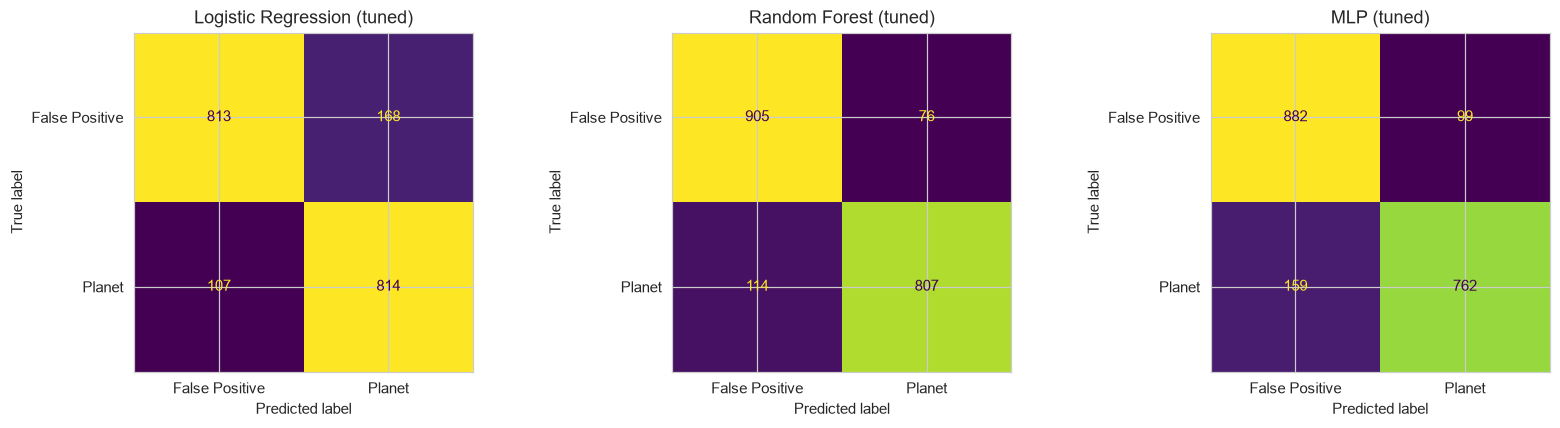

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (y_pred, _)) in zip(axes, tuned_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["False Positive", "Planet"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} (tuned)")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/outputs_confusion_matrices.png", bbox_inches="tight")
plt.show()

### 12.2 ROC curves

Each curve traces the trade-off between true and false positive rates as the
decision threshold moves from 0 to 1. The dashed diagonal is random guessing,
so the further a curve sits above it, the better the model separates the two
classes regardless of where the threshold is placed.

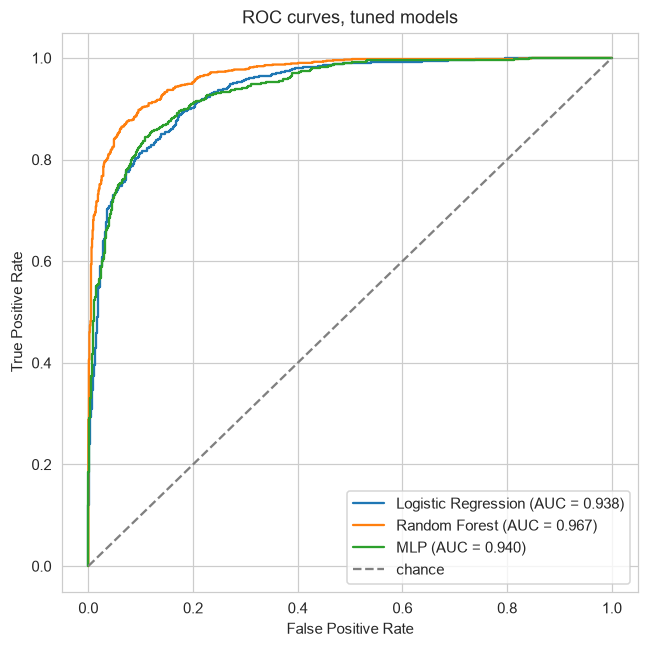

In [27]:
plt.figure(figsize=(6, 6))
for name, (_, y_proba) in tuned_preds.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves, tuned models")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/outputs_roc_curves.png", bbox_inches="tight")
plt.show()

## 13. Which features mattered

The specification requires some investigation of interpretability, and the two
models offer different views of it.

The Random Forest exposes **impurity-based importances**: how much each feature
reduces impurity across all splits in the forest. These are always positive and
say nothing about direction.

Logistic Regression exposes **coefficients**. Because the features were
standardised, they are directly comparable, and the sign is meaningful —
positive pushes a prediction towards "planet", negative towards "false positive".

Feature names are read off the fitted imputer rather than from a separately kept
list, so they cannot drift out of step with what the model was actually trained
on.

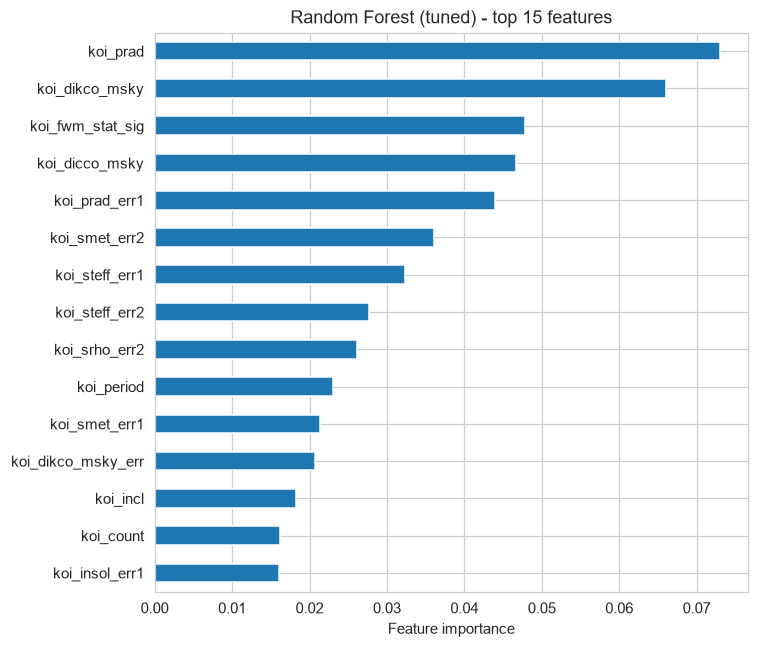

In [28]:
rf_model = tuned_fitted["Random Forest"].named_steps["model"]
rf_feature_names = tuned_fitted["Random Forest"].named_steps["impute"].get_feature_names_out()

importances = pd.Series(
    rf_model.feature_importances_,
    index=rf_feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
importances.iloc[::-1].plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Random Forest (tuned) - top 15 features")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/outputs_feature_importance.png", bbox_inches="tight")
plt.show()

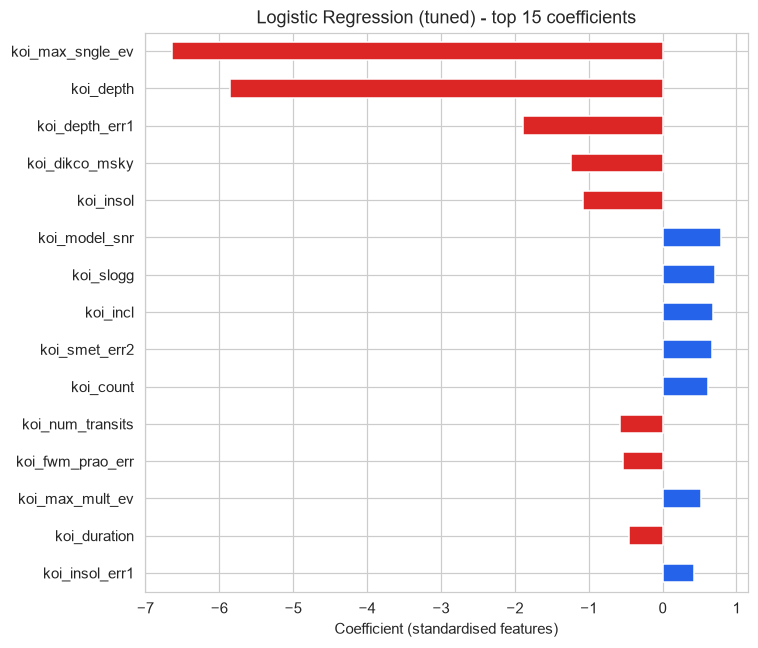

In [29]:
lr_model = tuned_fitted["Logistic Regression"].named_steps["model"]
lr_feature_names = tuned_fitted["Logistic Regression"].named_steps["impute"].get_feature_names_out()

# Sorted by absolute value so the strongest effects come first regardless of sign.
coef = pd.Series(
    lr_model.coef_[0],
    index=lr_feature_names
).sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(7, 6))
# Blue pushes towards "planet", red towards "false positive".
colors = ["#2563EB" if v > 0 else "#DC2626" for v in coef.iloc[::-1]]
coef.iloc[::-1].plot(kind="barh", color=colors)

plt.xlabel("Coefficient (standardised features)")
plt.title("Logistic Regression (tuned) - top 15 coefficients")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/outputs_lr_coefficients.png", bbox_inches="tight")
plt.show()

## 14. Saving the trained pipelines

Each saved file is the **whole pipeline**, not just the classifier, so the
imputer and scaler travel with their fitted statistics. The Streamlit app can
then call `.predict()` on raw KOI columns without having to reproduce any
preprocessing itself — which also removes the risk of the app preprocessing
differently from the notebook.

In [30]:
os.makedirs("models", exist_ok=True)

for name, pipe in tuned_fitted.items():
    fname = name.lower().replace(" ", "_")
    joblib.dump(pipe, f"models/{fname}_tuned_pipeline.joblib")

# model_feature_cols, not final_cols: the models were trained after rowid was
# dropped, so final_cols would claim one feature more than the models expect.
joblib.dump(model_feature_cols, "models/feature_columns.joblib")

print("Saved tuned pipelines to ./models/")
print(f"Feature list saved with {len(model_feature_cols)} columns")

Saved tuned pipelines to ./models/
Feature list saved with 69 columns


## 15. Exporting results

Every number the Streamlit app and the dissertation report is written out here,
so nothing has to be copied by hand or hard-coded anywhere else. The figures
were already saved into `results/` as they were produced.

In [31]:
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(f"{results_dir}/model_comparison.csv", index=False)
pd.DataFrame(cv_results).to_csv(f"{results_dir}/cross_validation_scores.csv", index=False)
pd.DataFrame(tuning_summary).to_csv(f"{results_dir}/tuning_summary.csv", index=False)
leakage_table.to_csv(f"{results_dir}/leakage_columns_removed.csv", index=False)

# Records how the feature count narrowed at each stage, for the methodology chapter.
feature_summary = pd.DataFrame([{
    "candidate_numeric_columns": X_train_raw.shape[1],
    "after_missingness_filter": len(keep_cols),
    "after_correlation_filter": len(final_cols),
    "training_rows": len(X_train),
    "test_rows": len(X_test),
    "unique_host_stars_train": groups_train.nunique(),
}])
feature_summary.to_csv(f"{results_dir}/feature_preparation_summary.csv", index=False)

best_row = results_df[results_df["Version"] == "Tuned"].sort_values("F1-score", ascending=False).iloc[0]
summary_text = f"""Exoplanet Detection - Results Summary
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}

Best model (tuned, by F1-score): {best_row['Model']}
  Precision: {best_row['Precision']}
  Recall:    {best_row['Recall']}
  F1-score:  {best_row['F1-score']}
  ROC-AUC:   {best_row['ROC-AUC']}
  Accuracy:  {best_row['Accuracy']}

See model_comparison.csv, cross_validation_scores.csv, tuning_summary.csv,
leakage_columns_removed.csv and feature_preparation_summary.csv for full detail.
"""

# encoding="utf-8" so the file reads back identically on any platform.
with open(f"{results_dir}/summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print(f"Saved to ./{results_dir}/:")
print(sorted(os.listdir(results_dir)))

Exoplanet Detection - Results Summary
Generated: 2026-08-21 09:06

Best model (tuned, by F1-score): Random Forest
  Precision: 0.914
  Recall:    0.876
  F1-score:  0.895
  ROC-AUC:   0.967
  Accuracy:  0.9

See model_comparison.csv, cross_validation_scores.csv, tuning_summary.csv,
leakage_columns_removed.csv and feature_preparation_summary.csv for full detail.

Saved to ./results/:
['cross_validation_scores.csv', 'feature_preparation_summary.csv', 'leakage_columns_removed.csv', 'model_comparison.csv', 'outputs_confusion_matrices.png', 'outputs_correlation.png', 'outputs_feature_importance.png', 'outputs_lr_coefficients.png', 'outputs_missingness.png', 'outputs_roc_curves.png', 'summary.txt', 'tuning_summary.csv']


## 16. A worked example for the demo

The Streamlit app needs a single record that is genuinely classified as a false
positive, so the demonstration can show both outcomes rather than only the
positive case.

Note this uses `pipelines["Random Forest"]`, which is the **baseline** fit from
section 9 — `pipe.fit()` modified those objects in place. The tuned models live
in `tuned_fitted`. For picking one illustrative row either is fine, since the
two agree on the overwhelming majority of the test set.

In [32]:
rf_baseline = pipelines["Random Forest"]
test_predictions = rf_baseline.predict(X_test)

# Rows the model assigns to class 0 (not an exoplanet).
negative_indices = np.where(test_predictions == 0)[0]
print(f"Number of test records predicted as NOT an exoplanet: {len(negative_indices)}")

example_idx = negative_indices[0]

print("\nExample:")
print(f"Test row index: {example_idx}")
print(f"Actual label: {y_test.iloc[example_idx]}")
print(f"Model prediction: {test_predictions[example_idx]}")

Number of test records predicted as NOT an exoplanet: 1012

Example:
Test row index: 4
Actual label: 0
Model prediction: 0


In [33]:
# test_idx maps the position within the test set back to the original row in
# feature_df, so the exported CSV keeps every original column.
false_positive_example = feature_df.iloc[[test_idx[example_idx]]].copy()
false_positive_example.to_csv("test_false_positive_example.csv", index=False)

print("Saved: test_false_positive_example.csv")
print(f"Actual label: {y_test.iloc[example_idx]} (0 = false positive)")

Saved: test_false_positive_example.csv
Actual label: 0 (0 = false positive)
